#MNIST

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
print(mnist.data.shape)

(70000, 784)


In [1]:
import pandas as pd
print(pd.__version__)

3.0.5


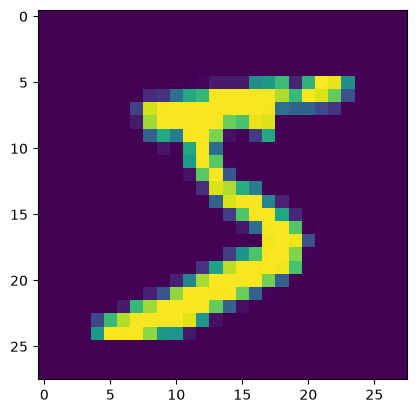

5


In [3]:
import matplotlib.pyplot as plt
plt.imshow(mnist.data[0].reshape(28,28) )
plt.show()

print(mnist.target[0])

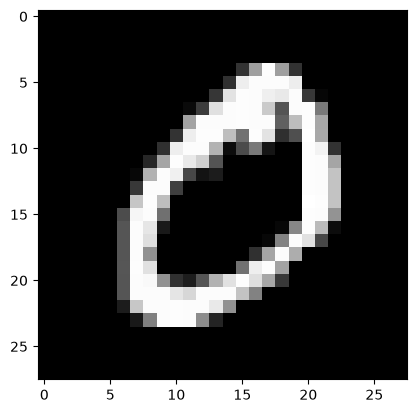

0


In [7]:
plt.imshow(mnist.data[1].reshape(28,28), cmap='grey')
plt.show()
print(mnist.target[1])

In [ ]:
X= mnist.data
y = mnist.target
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=96 #fixing the random shuffling order
)

#KNN Classifier

In [15]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Features and labels
X = mnist.data
y = mnist.target

# Scale
X = X / 255.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=96
)

# Create KNN model
model = KNeighborsClassifier(n_neighbors=3)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
X= mnist.data
y = mnist.target
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=96 #fixing the random shuffling order
)
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9721428571428572
Accuracy: 0.9705714285714285


#MINIMUM DISTANCE CLASSIFIER

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

# Scale
X = X / 255.0

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=96
)

# Find center of each class
class_centers = []

for digit in range(10):
    class_data = X_train[y_train == str(digit)]
    center = np.mean(class_data, axis=0)
    class_centers.append(center)

class_centers = np.array(class_centers)

# Prediction
predictions = []

for image in X_test:
    distances = []

    for center in class_centers:
        distance = np.linalg.norm(image - center)
        distances.append(distance)

    predictions.append(np.argmin(distances))

predictions = np.array(predictions).astype(str)

# Accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8105714285714286


#linear regression

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([20, 30, 40, 50, 60])

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

print("Predictions:", y_pred)
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

Predictions: [20. 30. 40. 50. 60.]
Slope: [10.]
Intercept: 10.000000000000007
MSE: 1.262177448353619e-29


#non-linear regression

In [5]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1, 4, 9, 16, 25])

# Convert X into polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Create and train model
model = LinearRegression()
model.fit(X_poly, y)

# Predict
y_pred = model.predict(X_poly)

print("Predictions:", y_pred)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Error
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

Predictions: [ 1.  4.  9. 16. 25.]
Coefficients: [ 0.00000000e+00 -8.77076189e-15  1.00000000e+00]
Intercept: 7.105427357601002e-15
MSE: 1.5146129380243426e-29
